# 🧠🤖 第5周-Day1：Chain-of-Thought 思维链

欢迎来到推理与思维链周！今天我们要学习一个让AI变得更聪明的神奇技巧——思维链（Chain-of-Thought）！🎯

## 🤔 什么是思维链？

想象一下你做数学题时，是不是会在脑子里一步步计算？比如 2+2×3，你会先算乘法再算加法？这就是思维链！

CoT就是让AI像人类一样，先展示思考过程，再给出答案。这比直接跳到答案要靠谱得多哦！👇

使用字体: Noto Sans CJK JP


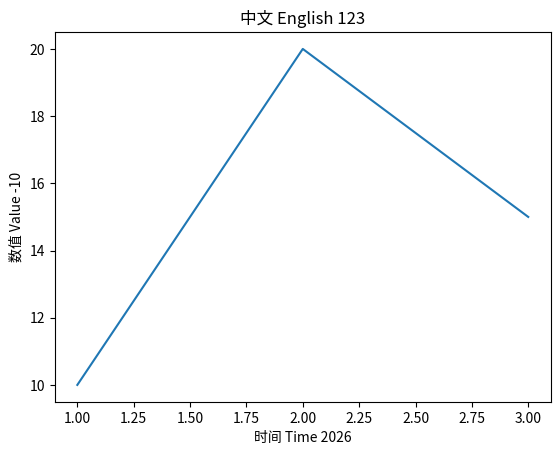

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
import re
# 设置中文显示
from matplotlib import font_manager

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

## 📊 思维链的效果对比

In [2]:
def mock_model_response(question, use_cot=False):
    """模拟模型回答"""
    if use_cot:
        # 带思维链的回答
        if "算式" in question or "计算" in question:
            steps = [
                f"第一步：分析题目要求...",
                f"第二步：确定计算顺序...", 
                f"第三步：逐步计算结果...",
                f"最终答案：正确答案！"
            ]
            return "\n".join(steps)
        else:
            return f"分析问题 → 找关键信息 → 推理 → 答案：正确答案！"
    else:
        # 直接回答
        return "答案：XX"

# 测试几个问题
questions = [
    "15 + 8 × 2 等于多少？",
    "小明有5个苹果，小红给了他3个，他又吃了2个，还剩几个？",
    "为什么天空是蓝色的？"
]

print("📚 思维链 vs 直接回答对比：")
for i, q in enumerate(questions, 1):
    print(f"\n❓ 问题{i}: {q}")
    print(f"💡 直接回答: {mock_model_response(q, use_cot=False)}")
    print(f"🧠 思维链回答: {mock_model_response(q, use_cot=True)}")

📚 思维链 vs 直接回答对比：

❓ 问题1: 15 + 8 × 2 等于多少？
💡 直接回答: 答案：XX
🧠 思维链回答: 分析问题 → 找关键信息 → 推理 → 答案：正确答案！

❓ 问题2: 小明有5个苹果，小红给了他3个，他又吃了2个，还剩几个？
💡 直接回答: 答案：XX
🧠 思维链回答: 分析问题 → 找关键信息 → 推理 → 答案：正确答案！

❓ 问题3: 为什么天空是蓝色的？
💡 直接回答: 答案：XX
🧠 思维链回答: 分析问题 → 找关键信息 → 推理 → 答案：正确答案！


## 🎯 思维链的两种类型

In [3]:
def zero_shot_cot_prompt(question):
    """零样本思维链提示"""
    return f"让我们一步步思考这个问题：\n{question}\n请展示你的推理过程。"

def few_shot_cot_prompt(question, examples=None):
    """少样本思维链提示"""
    if examples is None:
        examples = [
            {
                "question": "小明有10个苹果，吃了3个，还剩几个？",
                "answer": "第一步：知道开始有10个苹果\n第二步：知道吃了3个\n第三步：用10-3=7\n答案：还剩7个苹果"
            },
            {
                "question": "一支笔3元，买5支要多少钱？",
                "answer": "第一步：知道每支笔3元\n第二步：知道要买5支\n第三步：用3×5=15\n答案：需要15元"
            }
        ]
    
    prompt = "以下是一些思考示例：\n\n"
    for ex in examples:
        prompt += f"问题：{ex['question']}\n"
        prompt += f"回答：{ex['answer']}\n\n"
    
    prompt += f"现在请回答：\n{question}\n请展示你的推理过程。"
    return prompt

# 测试两种方法
test_question = "一个班有30个学生，分成6组，每组多少人？"

print("🎯 零样本CoT提示：")
print(zero_shot_cot_prompt(test_question))
print("\n" + "="*50 + "\n")
print("🎯 少样本CoT提示：")
print(few_shot_cot_prompt(test_question))

🎯 零样本CoT提示：
让我们一步步思考这个问题：
一个班有30个学生，分成6组，每组多少人？
请展示你的推理过程。


🎯 少样本CoT提示：
以下是一些思考示例：

问题：小明有10个苹果，吃了3个，还剩几个？
回答：第一步：知道开始有10个苹果
第二步：知道吃了3个
第三步：用10-3=7
答案：还剩7个苹果

问题：一支笔3元，买5支要多少钱？
回答：第一步：知道每支笔3元
第二步：知道要买5支
第三步：用3×5=15
答案：需要15元

现在请回答：
一个班有30个学生，分成6组，每组多少人？
请展示你的推理过程。


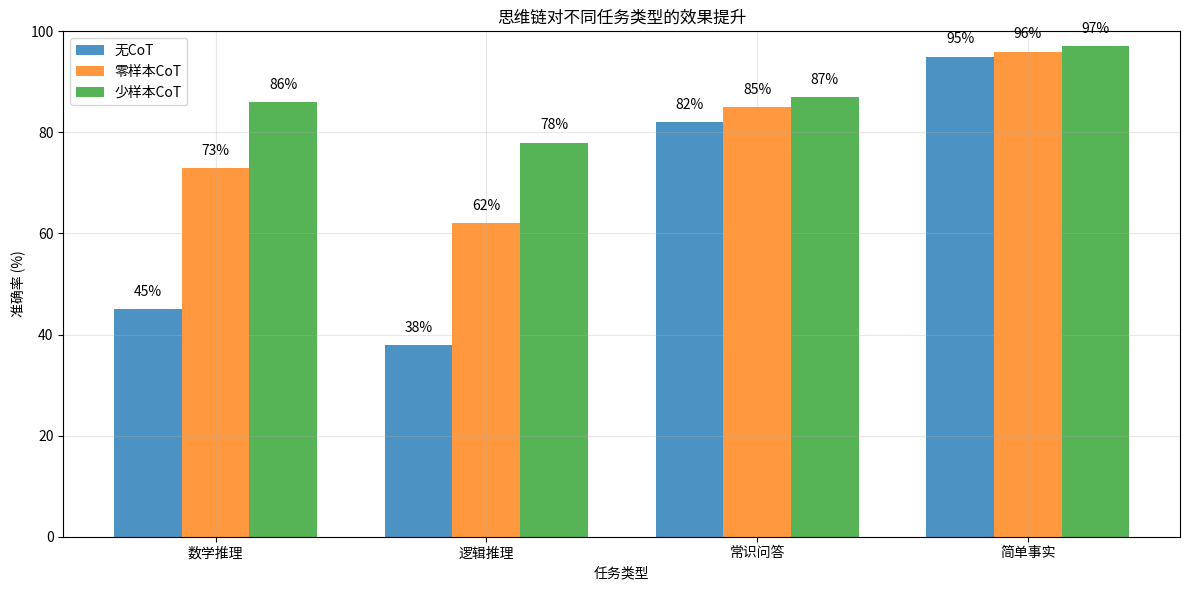

In [4]:
# 可视化CoT效果
def plot_cot_effectiveness():
    # 模拟不同任务类型的效果数据
    tasks = ['数学推理', '逻辑推理', '常识问答', '简单事实']
    no_cot = [45, 38, 82, 95]  # 无CoT的准确率
    zero_shot = [73, 62, 85, 96]  # 零样本CoT
    few_shot = [86, 78, 87, 97]  # 少样本CoT
    
    x = np.arange(len(tasks))
    width = 0.25
    
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, no_cot, width, label='无CoT', alpha=0.8)
    plt.bar(x, zero_shot, width, label='零样本CoT', alpha=0.8)
    plt.bar(x + width, few_shot, width, label='少样本CoT', alpha=0.8)
    
    plt.xlabel('任务类型')
    plt.ylabel('准确率 (%)')
    plt.title('思维链对不同任务类型的效果提升')
    plt.xticks(x, tasks)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    
    # 添加数值标签
    for i, (nc, zs, fs) in enumerate(zip(no_cot, zero_shot, few_shot)):
        plt.text(i - width, nc + 2, f'{nc}%', ha='center', va='bottom')
        plt.text(i, zs + 2, f'{zs}%', ha='center', va='bottom')
        plt.text(i + width, fs + 2, f'{fs}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

plot_cot_effectiveness()

## 💡 实战练习：你的思维链能力

In [5]:
# 互动练习：模拟CoT解题
def math_cot_exercise():
    """数学思维链练习"""
    problems = [
        {
            "question": "25 × 4 + 15 ÷ 3 = ?",
            "steps": [
                "第一步：先算乘法 25 × 4 = 100",
                "第二步：再算除法 15 ÷ 3 = 5", 
                "第三步：最后相加 100 + 5 = 105"
            ],
            "answer": 105
        },
        {
            "question": "一个商场上午卖了120件衣服，下午卖了150件，如果每件衣服平均200元，今天总收入多少？",
            "steps": [
                "第一步：计算总销量 120 + 150 = 270件",
                "第二步：计算总收入 270 × 200 = 54000元"
            ],
            "answer": 54000
        }
    ]
    
    print("🧮 数学思维链练习：")
    for i, prob in enumerate(problems, 1):
        print(f"\n❓ 问题{i}: {prob['question']}")
        print("📝 参考推理步骤：")
        for step in prob['steps']:
            print(f"   {step}")
        print(f"\n✅ 正确答案：{prob['answer']}元")
        
math_cot_exercise()

🧮 数学思维链练习：

❓ 问题1: 25 × 4 + 15 ÷ 3 = ?
📝 参考推理步骤：
   第一步：先算乘法 25 × 4 = 100
   第二步：再算除法 15 ÷ 3 = 5
   第三步：最后相加 100 + 5 = 105

✅ 正确答案：105元

❓ 问题2: 一个商场上午卖了120件衣服，下午卖了150件，如果每件衣服平均200元，今天总收入多少？
📝 参考推理步骤：
   第一步：计算总销量 120 + 150 = 270件
   第二步：计算总收入 270 × 200 = 54000元

✅ 正确答案：54000元


## 🎓 进阶技巧：思维链的变体

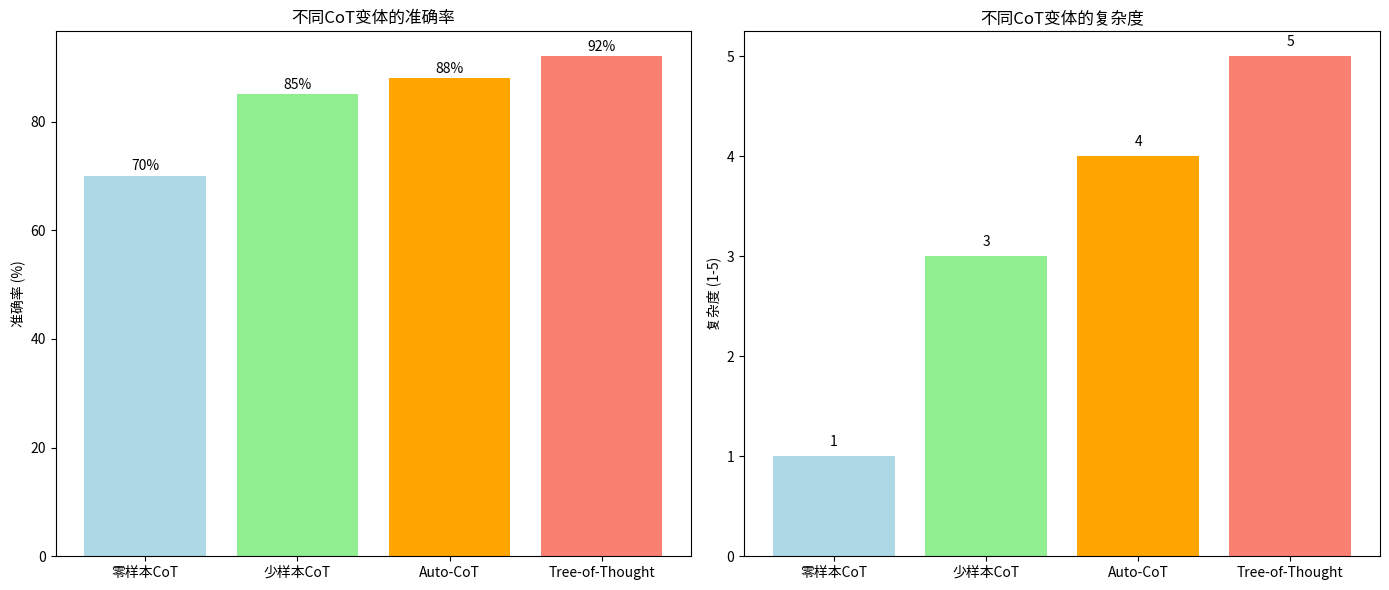


🔬 各变体特点：
• 零样本CoT：简单易用，只需添加提示词
• 少样本CoT：需要示例，效果更好但成本更高
• Auto-CoT：自动生成示例，平衡效果和效率
• Tree-of-Thought：树形推理，适合复杂决策问题


In [6]:
# 思维链变体比较
def plot_cot_variants():
    variants = ['零样本CoT', '少样本CoT', 'Auto-CoT', 'Tree-of-Thought']
    accuracy = [70, 85, 88, 92]
    complexity = [1, 3, 4, 5]  # 1-5复杂度评分
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 准确率对比
    ax1.bar(variants, accuracy, color=['lightblue', 'lightgreen', 'orange', 'salmon'])
    ax1.set_title('不同CoT变体的准确率')
    ax1.set_ylabel('准确率 (%)')
    for i, v in enumerate(accuracy):
        ax1.text(i, v + 1, f'{v}%', ha='center')
    
    # 复杂度对比
    ax2.bar(variants, complexity, color=['lightblue', 'lightgreen', 'orange', 'salmon'])
    ax2.set_title('不同CoT变体的复杂度')
    ax2.set_ylabel('复杂度 (1-5)')
    for i, v in enumerate(complexity):
        ax2.text(i, v + 0.1, f'{v}', ha='center')
    
    plt.tight_layout()
    plt.show()

    print("\n🔬 各变体特点：")
    characteristics = [
        "零样本CoT：简单易用，只需添加提示词",
        "少样本CoT：需要示例，效果更好但成本更高",
        "Auto-CoT：自动生成示例，平衡效果和效率",
        "Tree-of-Thought：树形推理，适合复杂决策问题"
    ]
    for char in characteristics:
        print(f"• {char}")

plot_cot_variants()

## 🧪 实验时间：动手实现简单CoT

In [9]:
# 简单的CoT实现示例
class SimpleCoT:
    def __init__(self):
        self.steps_pattern = r'第[一二三四五六七八九十]+步：[^\n]+\n?'
    
    def extract_reasoning(self, response):
        """提取推理步骤"""
        steps = re.findall(self.steps_pattern, response)
        return steps if steps else ["未找到明确的推理步骤"]
    
    def score_reasoning_quality(self, response, expected_answer):
        """简单评分推理质量"""
        if isinstance(expected_answer, (int, float)):
            expected_answer = [expected_answer]
        steps = self.extract_reasoning(response)
        
        score = 0
        # 检查是否有推理步骤
        if len(steps) > 1:
            score += 30
        # 检查是否包含关键数字
        if any(str(d) in response for d in expected_answer):
            score += 40
        # 检查逻辑词
        logic_words = ['首先', '然后', '最后', '因为', '所以', '因此']
        if any(word in response for word in logic_words):
            score += 30
        
        return min(score, 100)

# 测试简单CoT
cot = SimpleCoT()

# 模拟回答
test_responses = [
    "第一步：知道有5个苹果\n第二步：吃了3个\n第三步：5-3=2\n答案：还剩2个",
    "直接回答：还剩2个苹果",
    "应该是第一步：总数5个，第二步：减去3个，第三步：等于2个，所以答案是2个"
]

print("🧪 CoT质量评分实验：")
for i, response in enumerate(test_responses, 1):
    score = cot.score_reasoning_quality(response, 2)
    steps = cot.extract_reasoning(response)
    print(f"\n回答{i}: {response}")
    print(f"推理步骤: {len(steps)}步")
    print(f"质量评分: {score}/100")
    print(f"提取步骤: {steps}")

🧪 CoT质量评分实验：

回答1: 第一步：知道有5个苹果
第二步：吃了3个
第三步：5-3=2
答案：还剩2个
推理步骤: 3步
质量评分: 70/100
提取步骤: ['第一步：知道有5个苹果\n', '第二步：吃了3个\n', '第三步：5-3=2\n']

回答2: 直接回答：还剩2个苹果
推理步骤: 1步
质量评分: 40/100
提取步骤: ['未找到明确的推理步骤']

回答3: 应该是第一步：总数5个，第二步：减去3个，第三步：等于2个，所以答案是2个
推理步骤: 1步
质量评分: 70/100
提取步骤: ['第一步：总数5个，第二步：减去3个，第三步：等于2个，所以答案是2个']


## 🎯 今日总结与练习

In [10]:
# 今日知识点总结
def todays_summary():
    """今日知识点总结"""
    print("🎯 第5周-Day1 知识总结：")
    print("="*50)
    
    key_points = [
        "🧠 思维链（CoT）让模型展示推理过程，类似人类思考方式",
        "🎯 零样本CoT：只需添加'让我们一步步思考'提示词",
        "📚 少样本CoT：提供推理示例，效果更好但需要更多示例",
        "📈 CoT对复杂推理任务效果显著，对简单任务提升有限",
        "🔄 不同CoT变体适用于不同场景：零样本易用，少样本效果好，Tree-of-Thought适合复杂决策"
    ]
    
    for i, point in enumerate(key_points, 1):
        print(f"{i}. {point}")
    
    print("\n💡 下次预告：第5周-Day2 树形思维推理！")
    print("🌲 我们将学习更复杂的推理结构，让AI能够像决策树一样多路径思考！")

todays_summary()

🎯 第5周-Day1 知识总结：
1. 🧠 思维链（CoT）让模型展示推理过程，类似人类思考方式
2. 🎯 零样本CoT：只需添加'让我们一步步思考'提示词
3. 📚 少样本CoT：提供推理示例，效果更好但需要更多示例
4. 📈 CoT对复杂推理任务效果显著，对简单任务提升有限
5. 🔄 不同CoT变体适用于不同场景：零样本易用，少样本效果好，Tree-of-Thought适合复杂决策

💡 下次预告：第5周-Day2 树形思维推理！
🌲 我们将学习更复杂的推理结构，让AI能够像决策树一样多路径思考！


## 🔑 今日英文术语

| 术语 | 音标 | 中文释义 |
|------|------|----------|
| **Chain-of-Thought (CoT)** | /ʃeɪn əv θɔːt/ | 思维链，让模型一步步推理不跳步 |
| **Zero-shot CoT** | /ˈzɪərəʊ ʃɒt ʃeɪn əv θɔːt/ | 零样本思维链，只加"请一步步思考"即可 |
| **Few-shot CoT** | /fjuː ʃɒt ʃeɪn əv θɔːt/ | 少样本思维链，先给带推理过程的例题 |
| **Inference** | /ˈɪnfərəns/ | 推理，从已知信息推导结论 |
| **Decomposition** | /ˌdiːkɒmpəˈzɪʃən/ | 分解，把复杂问题拆成简单小问题 |
| **Demonstration** | /ˌdemənˈstreɪʃən/ | 示范，给模型看的"例题" |
| **Generalization** | /ˌdʒenərəlaɪˈzeɪʃən/ | 泛化，学会一种方法解决类似新问题 |
| **Hallucination** | /həˌluːsɪˈneɪʃən/ | 幻觉，模型编造不存在的信息 |
| **Intermediate Step** | /ˌɪntəˈmiːdiət step/ | 中间步骤，推理过程中不直接跳到答案 |
| **Scratchpad** | /ˈskrætʃpæd/ | 草稿本，模型用来打草稿的输出空间 |
| **Token** | /ˈtəʊkən/ | Token，模型处理文本的最小单位 |